In [1]:
import pandas as pd
import numpy as np
import datetime
from scorepi import *
from epiweeks import Week
import matplotlib.pyplot as plt
from collections import defaultdict
import seaborn as sns
import datetime
from datetime import datetime
from datetime import timedelta
from pathlib import Path
import matplotlib as mpl
import random
from numba import njit
import warnings
warnings.filterwarnings('ignore')

In [2]:
from numba import njit
@njit
def energyscore(X,y):
    # X is matrix of trajectories, y is observations
    ES = 0
    N = X.shape[0]
    for i in range(N):
        ES += np.sqrt(np.sum((X[i]-y)**2))/N
    for i in range(N):
        for j in range(N):
            ES -= np.sqrt(np.sum((X[i]-X[j])**2))/(2*N**2)
    return ES


In [3]:
from numba import njit
@njit
def energyscore_multipletargets(X,y):
    # X is matrix of trajectories, y is observations
    ES = 0
    N = X.shape[0]
    for i in range(N):
        ES += np.sqrt(np.sum(((X[i]-y)**2)/(np.sum(y,axis=1)[:, np.newaxis])**2))/ N
    for i in range(N):
        for j in range(N):
            ES -= np.sqrt(np.sum(((X[i]-X[j])**2)/(np.sum(y,axis=1)[:, np.newaxis])**2))/(2*N**2)
    return ES


# COVID SMH Analysis

In [4]:
def pull_surveillance_data():
    #flu surveillance data
    
    url = f"https://raw.githubusercontent.com/CDCgov/covid19-forecast-hub/refs/heads/main/target-data/covid-hospital-admissions.csv"
    return pd.read_csv(url, dtype={'location':str})



def pull_covid_scenario_modeling_hub_predictions(model,dates):
    """pull_scenario_modeling_hub_predictions. Load predictions of the model saved by the scenario modeling
    hub.

    Parameters
    ----------
    model : str
        Model name on thhe
    dates : list or string
        List of potential dates in the iso format, e.g., 'yyyy-mm-dd', for the submission.
    """
    predictions = None
    if isinstance(dates,str):
        dates = [dates]
    for date in dates:
        url = f"https://raw.githubusercontent.com/midas-network/covid19-scenario-modeling-hub/master/model-output/{model}/{date}-{model}"
        for ext in [".gz.parquet", ".parquet"]:
                try:
                    predictions = pd.read_parquet(url+ext)
                    
                except:
                    pass

    if predictions is None:
        print(f"Data for model {model} and date {dates} unavailable")
    return predictions



# Multi-dimensional energy score for MOBS model

In [5]:
models = ['CFA-Scenarios', 'JHU_UNC-flepiMoP', 'MOBS_NEU-GLEAM_COVID', 'PSI-M_CoV_2025',
            'UIUC-IMMCYC', 'UNCC-Hierbin', 'UT-ImmunoSEIRS', 'UVA-adaptive']

modelmap = {'MOBS_NEU-GLEAM_COVID':'Model A', 'CFA-Scenarios':'Model B', 'JHU_UNC-flepiMoP': 'Model C', 
            'PSI-M_CoV_2025':'Model D', 'UIUC-IMMCYC':'Model E', 'UNCC-Hierbin':'Model F', 
            'UT-ImmunoSEIRS':'Model G', 'UVA-adaptive':'Model H'}

In [6]:
#hospitalizations
target = 'hospitalization'
incidence=True
hosp = pull_surveillance_data().rename(columns={'target_end_date':'date'})
hosp['date'] = pd.to_datetime(hosp['date'])
hosp = hosp[(hosp.date>=pd.to_datetime('2025-05-03'))].sort_values(by=['date']).reset_index().drop(columns=\
                                                                        [ 'index'])

hosp = hosp[(hosp.location != '72') &(hosp.location!='66')]

#hosp = hosp[(hosp.date >= pd.to_datetime('2024-08-17')) & (hosp.date<='2025-06-07')]

In [8]:
modelsall = ['MOBS_NEU-GLEAM_COVID']

start_week = pd.to_datetime('2025-05-03')
max_date = pd.to_datetime(hosp.date.max())


predictionsall = pd.DataFrame()
for model in modelsall:
    df = pd.read_parquet(f'../coviddat/{model}_rd4_hosp.pq')
    print(model, len(df.location.unique())) 
    
    predictionsall = pd.concat([predictionsall, df])   
    
# filter by dates with data
predictionsall = predictionsall[predictionsall.target_end_date <= max_date]    
     
    

MOBS_NEU-GLEAM_COVID 52


In [9]:
dfmobs = predictionsall[(predictionsall.Model=='MOBS_NEU-GLEAM_COVID') & (predictionsall.target=='inc hosp') &\
                       (predictionsall.output_type == 'sample')]

In [16]:
dfmobs

,origin_date,scenario_id,location,target,horizon,age_group,output_type,output_type_id,run_grouping,stochastic_run,value,Model,target_end_date
0,2025-04-27,A-2025-04-01,01,inc hosp,20,0-130,sample,NaN,0.0,0.0,5.0,MOBS_NEU-GLEAM_COVID,2025-09-13
1,2025-04-27,B-2025-04-01,01,inc hosp,20,0-130,sample,NaN,0.0,0.0,4.6,MOBS_NEU-GLEAM_COVID,2025-09-13
2,2025-04-27,C-2025-04-01,01,inc hosp,20,0-130,sample,NaN,0.0,0.0,4.5,MOBS_NEU-GLEAM_COVID,2025-09-13
3,2025-04-27,D-2025-04-01,01,inc hosp,20,0-130,sample,NaN,0.0,0.0,5.4,MOBS_NEU-GLEAM_COVID,2025-09-13
4,2025-04-27,E-2025-04-01,01,inc hosp,20,0-130,sample,NaN,0.0,0.0,3.9,MOBS_NEU-GLEAM_COVID,2025-09-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13082935,2025-04-27,A-2025-04-01,56,inc hosp,36,65-130,sample,NaN,15599.0,15599.0,27.9,MOBS_NEU-GLEAM_COVID,2026-01-03
13082936,2025-04-27,B-2025-04-01,56,inc hosp,36,65-130,sample,NaN,15599.0,15599.0,14.9,MOBS_NEU-GLEAM_COVID,2026-01-03
13082937,2025-04-27,C-2025-04-01,56,inc hosp,36,65-130,sample,NaN,15599.0,15599.0,12.0,MOBS_NEU-GLEAM_COVID,2026-01-03
13082938,2025-04-27,D-2025-04-01,56,inc hosp,36,65-130,sample,NaN,15599.0,15599.0,6.4,MOBS_NEU-GLEAM_COVID,2026-01-03


In [17]:
obs = np.array([np.array(hosp[hosp.location == i].value) for \
                     i in dfmobs.location.unique()])
locations = list(dfmobs.location.unique())

energyscores_locations = pd.DataFrame()

mask = ((dfmobs.target_end_date <= hosp.date.max()) &(dfmobs.target_end_date >= hosp.date.min()) &
    (dfmobs.Model == 'MOBS_NEU-GLEAM_COVID') &(dfmobs.age_group == '0-130') & (~dfmobs.location.isin(['72', '66'])))

dfmobs_filtered = dfmobs[mask].copy()

results = []  


for it in range(50):
    print(it)
    for scenario in ['A', 'B', 'C', 'D', 'E',]:
        dfall = dfmobs_filtered[dfmobs_filtered.scenario_id == scenario + '-2025-04-01']

        if dfall.empty:
            continue
            
        dfall['run_grouping'] = (dfall.groupby('location')['run_grouping']
                                .transform(lambda x: pd.factorize(x)[0] + 1))
            
        for loc in dfall.location.unique():
            loc_mask = dfall.location == loc
            original_ids = dfall.loc[loc_mask, 'run_grouping'].values
            unique_ids = np.unique(original_ids)
            shuffled = unique_ids.copy()
            np.random.shuffle(shuffled)
            mapping = dict(zip(unique_ids, shuffled))
            dfall.loc[loc_mask, 'run_grouping'] = (
                dfall.loc[loc_mask, 'run_grouping'].map(mapping)
            )


        dfall_sorted = dfall.sort_values('target_end_date')

        grouped = (dfall_sorted.groupby(['run_grouping', 'location'])['value'].apply(list))
        unstacked = grouped.unstack(fill_value=[])

        A = np.array(unstacked.values.tolist())

        ES = energyscore_multipletargets(A, obs)

        results.append({'Model': 'MOBS_NEU-GLEAM_COVID','Label': f'Scenario {scenario}',
            'location': 'US','energyscore': ES,'it': it })

energyscores_locations = pd.DataFrame(results)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


In [18]:
energyscores_locations.to_csv('../coviddat/multitarget_loc_MOBS_rd19.csv')

In [20]:
energyscores_locations

,Model,Label,location,energyscore,it
0,MOBS_NEU-GLEAM_COVID,Scenario A,US,170.332598,0
1,MOBS_NEU-GLEAM_COVID,Scenario B,US,117.690600,0
2,MOBS_NEU-GLEAM_COVID,Scenario C,US,118.409710,0
3,MOBS_NEU-GLEAM_COVID,Scenario D,US,99.293630,0
4,MOBS_NEU-GLEAM_COVID,Scenario E,US,97.722029,0
...,...,...,...,...,...
245,MOBS_NEU-GLEAM_COVID,Scenario A,US,170.332017,49
246,MOBS_NEU-GLEAM_COVID,Scenario B,US,117.693318,49
247,MOBS_NEU-GLEAM_COVID,Scenario C,US,118.416196,49
248,MOBS_NEU-GLEAM_COVID,Scenario D,US,99.289967,49


In [21]:
baseline = pd.read_csv('../coviddat/multitarget_loc_baseline_covid.csv')
baselinemed = baseline.energyscore.median()

energyscores_locations = pd.read_csv('../coviddat/multitarget_loc_MOBS_rd19.csv')
energyscores_locations['ES_ratio'] = energyscores_locations['energyscore'] / baselinemed


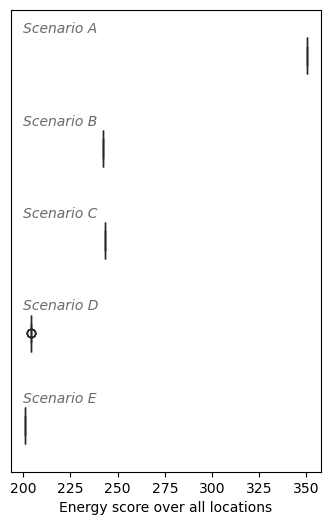

In [23]:
# plot multi-target energy score across all locations just for MOBS model
fig, ax = plt.subplots(1,1,figsize=(4,6), sharex=True)

my_order = list(energyscores_locations.Label.unique())
sns.boxplot(x='ES_ratio', y='Label', data=energyscores_locations, width=.4, showfliers=True, color='teal')
plt.ylabel('')
plt.yticks([])
plt.xlabel('Energy score over all locations')

a=0
for mod in list(my_order):
    plt.text(200,a-.25, mod, fontsize=10, style='italic', color='dimgray')
    a+=1



#plt.savefig('../figs/mulitargets_locations_MOBS.pdf')

In [24]:
energyscores_locations.groupby('Label').median().to_csv('../coviddat/multitarget_mobs_ratio_median_rd19.csv')

In [25]:
df_describe = energyscores_locations.drop(columns=['Unnamed: 0', 'location', 'it',
                                                   'Model']).groupby('Label').describe()['energyscore']

df_describe['range'] = df_describe['max'] - df_describe['min']
df_describe = df_describe.round(3)

In [26]:
df_describe

,count,mean,std,min,25%,50%,75%,max,range
Label,,,,,,,,,
Scenario A,50.0,170.331,0.002,170.325,170.329,170.331,170.332,170.336,0.010
Scenario B,50.0,117.696,0.004,117.688,117.694,117.696,117.699,117.704,0.017
Scenario C,50.0,118.411,0.004,118.400,118.408,118.411,118.414,118.417,0.017
Scenario D,50.0,99.288,0.006,99.269,99.285,99.287,99.291,99.302,0.033
Scenario E,50.0,97.724,0.009,97.705,97.719,97.725,97.730,97.745,0.041
